In [ ]:
import pickle
import numpy as np

In [ ]:
with open ('train_qa.txt','rb') as f:
  train_data = pickle.load (f)

In [ ]:
with open ('test_qa.txt','rb') as f:
  test_data = pickle.load (f)

In [ ]:
type (test_data)

list

In [ ]:
len (train_data)

10000

In [ ]:
len (test_data)

1000

In [ ]:
' '.join(train_data[0][1])

'Is Sandra in the hallway ?'

In [ ]:
train_data[3][2]

'yes'

In [ ]:
all_data = test_data + train_data

In [ ]:
len (all_data)

11000

In [ ]:
vocab = set ()
for story, question, answer in all_data:
  vocab = vocab.union(set(story))
  vocab = vocab.union(set(question))

In [ ]:
vocab.add('no')
vocab.add('yes')

In [ ]:
vocab_len = len(vocab) + 1

In [ ]:
# LONGEST STORY
all_story_lens = [len(data[0]) for data in all_data]

In [ ]:
#all_story_lens

In [ ]:
max_story_len = max (all_story_lens)

In [ ]:
max_story_len

156

In [ ]:
max_question_len = max ([len(data[1]) for data in all_data])

In [ ]:
max_question_len

6

In [ ]:
from keras.preprocessing.sequence import pad_sequences
from keras.preprocessing.text import Tokenizer

In [ ]:
tokenizer = Tokenizer(filters=[])
tokenizer.fit_on_texts(vocab)

In [ ]:
tokenizer.word_index

{'.': 1,
 'in': 2,
 'up': 3,
 'office': 4,
 'left': 5,
 'took': 6,
 'dropped': 7,
 'hallway': 8,
 'travelled': 9,
 'apple': 10,
 'the': 11,
 'milk': 12,
 'daniel': 13,
 'to': 14,
 'football': 15,
 'discarded': 16,
 'no': 17,
 'kitchen': 18,
 'mary': 19,
 'down': 20,
 'john': 21,
 'is': 22,
 'sandra': 23,
 '?': 24,
 'there': 25,
 'journeyed': 26,
 'yes': 27,
 'bathroom': 28,
 'garden': 29,
 'grabbed': 30,
 'back': 31,
 'picked': 32,
 'moved': 33,
 'went': 34,
 'bedroom': 35,
 'put': 36,
 'got': 37}

In [ ]:
train_story_text = []
train_question_text = []
trian_answer = []

In [ ]:
for story, question, answer in train_data:
  train_story_text.append(story)

In [ ]:
train_story_text [1]

['Mary',
 'moved',
 'to',
 'the',
 'bathroom',
 '.',
 'Sandra',
 'journeyed',
 'to',
 'the',
 'bedroom',
 '.',
 'Mary',
 'went',
 'back',
 'to',
 'the',
 'bedroom',
 '.',
 'Daniel',
 'went',
 'back',
 'to',
 'the',
 'hallway',
 '.']

In [ ]:
train_story_seq = tokenizer.texts_to_sequences (train_story_text)

In [ ]:
train_story_seq [0]

[19, 33, 14, 11, 28, 1, 23, 26, 14, 11, 35, 1]

In [ ]:
#train_story_text

In [ ]:
def vectorize_stories (data, word_index = tokenizer.word_index, max_story_len = max_story_len, max_question_len=max_question_len):
  # STORIES = X
  X = []
  #QUESTIONS Xq
  Xq = []
  # Y CORRECT ANSWER (yes/no)
  Y = []

  for story, query, answer in data:
    x = [word_index[word.lower()] for word in story]
    xq = [word_index[word.lower()] for word in query]

    y = np.zeros(len(word_index)+1)
    y[word_index[answer]] = 1

    X.append(x)
    Xq.append(xq)
    Y.append(y)

  return (pad_sequences(X, maxlen = max_story_len), pad_sequences(Xq, maxlen=max_question_len), np.array(Y))

In [ ]:
inputs_train, queries_train, answers_train = vectorize_stories(train_data)

In [ ]:
inputs_test, queries_test, answers_test = vectorize_stories(test_data)

In [ ]:
inputs_test

array([[ 0,  0,  0, ..., 11, 35,  1],
       [ 0,  0,  0, ..., 11, 29,  1],
       [ 0,  0,  0, ..., 11, 29,  1],
       ...,
       [ 0,  0,  0, ..., 11, 10,  1],
       [ 0,  0,  0, ..., 11, 29,  1],
       [ 0,  0,  0, ..., 10, 25,  1]], dtype=int32)

In [ ]:
answers_test

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
tokenizer.word_index['yes']

27

In [ ]:
tokenizer.word_index['no']

17

In [ ]:
sum(answers_test)

array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0., 503.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0., 497.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.])

In [ ]:
from keras.models import Sequential, Model

In [ ]:
from keras.layers import Embedding

In [ ]:
from keras.layers import Input, Activation, Dense, Permute, Dropout, add, dot, concatenate, LSTM

In [ ]:
# PLACEHOLDER shape = (max_story_Len, batch_size)
input_sequence = Input ((max_story_len, ))
question = Input ((max_question_len))

In [ ]:
vocab_size = len(vocab) + 1

In [ ]:
# INPUT ENCODER M
input_encoder_m = Sequential()
input_encoder_m.add(Embedding(input_dim=vocab_size, output_dim=64))
input_encoder_m.add(Dropout(0.3))

# (samples, story_maxLen, embedding_dim)

In [ ]:
# INPUT ENCODER C
input_encoder_c = Sequential()
input_encoder_c.add(Embedding(input_dim=vocab_size, output_dim=max_question_len))
input_encoder_c.add(Dropout(0.3))

# (samples, story_maxLen, max_question_Len)

In [ ]:
# QUESTION
question_encoder = Sequential()
question_encoder.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=max_question_len))
question_encoder.add(Dropout(0.3))

# (samples, query_maxLen, embedding_dim)

In [ ]:
# ENCODER (INPUT) => ENCODED
input_encoded_m = input_encoder_m(input_sequence)
input_encoded_c = input_encoder_c(input_sequence)
question_encoded = question_encoder (question)

In [ ]:
match = dot ([input_encoded_m, question_encoded], axes =(2,2))
match = Activation ('softmax')(match)

In [ ]:
response = add ([match, input_encoded_c])
response = Permute ((2,1))(response)

In [ ]:
answer = concatenate ([response, question_encoded])
answer = LSTM (32)(answer)

In [ ]:
answer = Dropout (0.5)(answer)
answer = Dense (vocab_size)(answer)

In [ ]:
answer = Activation ('softmax')(answer)

In [ ]:
model = Model ([input_sequence, question], answer)

In [ ]:
model.compile(optimizer = 'rmsprop', loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
history = model.fit([inputs_train, queries_train], answers_train, batch_size=32, epochs =100, validation_data=([inputs_test, queries_test], answers_test))

Epoch 1/100
313/313 [==============================] - 7s 22ms/step - loss: 0.6950 - accuracy: 0.4953 - val_loss: 0.6932 - val_accuracy: 0.5030
Epoch 2/100
313/313 [==============================] - 6s 20ms/step - loss: 0.6951 - accuracy: 0.4967 - val_loss: 0.6931 - val_accuracy: 0.5030
Epoch 3/100
313/313 [==============================] - 5s 15ms/step - loss: 0.6954 - accuracy: 0.4922 - val_loss: 0.6931 - val_accuracy: 0.5030
Epoch 4/100
313/313 [==============================] - 6s 18ms/step - loss: 0.6944 - accuracy: 0.5043 - val_loss: 0.6934 - val_accuracy: 0.5030
Epoch 5/100
313/313 [==============================] - 4s 14ms/step - loss: 0.6950 - accuracy: 0.4941 - val_loss: 0.6937 - val_accuracy: 0.4970
Epoch 6/100
313/313 [==============================] - 4s 14ms/step - loss: 0.6943 - accuracy: 0.5014 - val_loss: 0.6942 - val_accuracy: 0.5030
Epoch 7/100
313/313 [==============================] - 6s 18ms/step - loss: 0.6951 - accuracy: 0.4990 - val_loss: 0.6939 - val_accuracy:

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


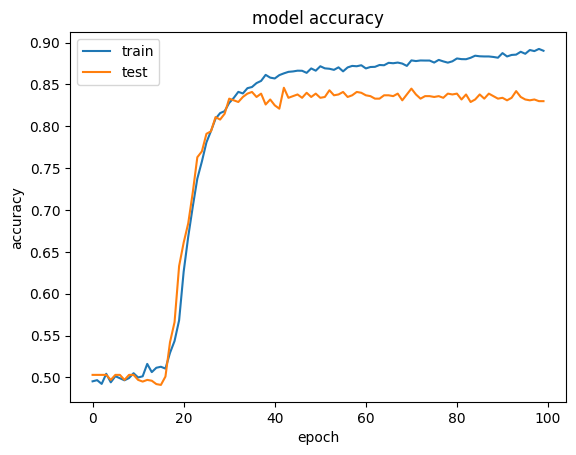

In [ ]:
import matplotlib.pyplot as plt

# Check available keys in history.history
print(history.history.keys())

# Use the correct key names from the printed keys
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()



In [ ]:
pred_results = model.predict(([inputs_test, queries_test]))

32/32 [==============================] - 0s 4ms/step


In [ ]:
val_max = np.argmax(pred_results[0])

In [ ]:
for key, val in tokenizer.word_index.items():
  if val == val_max:
    k = key

In [ ]:
k

'no'

In [ ]:
pred_results[0][val_max]

0.998725

In [ ]:
vocab

{'.',
 '?',
 'Daniel',
 'Is',
 'John',
 'Mary',
 'Sandra',
 'apple',
 'back',
 'bathroom',
 'bedroom',
 'discarded',
 'down',
 'dropped',
 'football',
 'garden',
 'got',
 'grabbed',
 'hallway',
 'in',
 'journeyed',
 'kitchen',
 'left',
 'milk',
 'moved',
 'no',
 'office',
 'picked',
 'put',
 'the',
 'there',
 'to',
 'took',
 'travelled',
 'up',
 'went',
 'yes'}

In [ ]:
my_story = "John left the kitchen . Sandra dropped the football in the garden ."

In [ ]:
my_story.split()

['John',
 'left',
 'the',
 'kitchen',
 '.',
 'Sandra',
 'dropped',
 'the',
 'football',
 'in',
 'the',
 'garden',
 '.']

In [ ]:
my_question = "Is the football in the garden ?"

In [ ]:
my_question.split()

['Is', 'the', 'football', 'in', 'the', 'garden', '?']

In [ ]:
mydata = [(my_story.split(), my_question.split(), 'yes')]

In [ ]:
my_story, my_ques, my_ans = vectorize_stories(mydata)

In [ ]:
pred_results = model.predict (([my_story, my_ques]))

1/1 [==============================] - 0s 29ms/step


In [ ]:
val_max = np.argmax(pred_results[0])

In [ ]:
for key, val in tokenizer.word_index.items():
  if val == val_max:
    k = key

In [ ]:
k

'yes'

In [ ]:
pred_results[0][val_max]

0.9847275